# Example - read MASSIMAL annotations
This notebook is a demonstration of reading and displaying annotations of hyperspectral images from the [MASSIMAL dataset](https://doi.org/10.11582/2025.00041). The example uses data from the ZIP file [massimal_vega_sola_20220823_hsi_annotation.zip](https://data.archive.sigma2.no/dataset/6b1f3cf3-6f88-4d6c-a5dc-79f03d6d51b3/download/vega/sola/aerial/hsi/20220823/massimal_vega_sola_20220823_hsi_annotation.zip)

To run this code on your own machine, create a virtual environment, install [NumPy](https://pypi.org/project/numpy/) and [PyCocoTools](https://pypi.org/project/pycocotools/), download and unzip the ZIP files, and update the paths in the third cell below. 

In [ ]:
# Imports
import pycocotools
from pycocotools.coco import COCO
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import json
import rich


In [2]:
# Paths - change these to point to your dataset and annotation files
example_hsi_dataset = Path(
    "/data/massimal/seabee-minio/vega/sola/aerial/hsi/20220823/"
    "massimal_vega_sola_202208231608-coast3_hsi/2a_reflectance"
)
annotation_dir = Path(
    "/data/massimal/seabee-minio/vega/sola/aerial/hsi/20220823/"
    "massimal_vega_sola_20220823_hsi_annotation"
)


In [3]:
# Fixed paths - don't change
rgb_folder_path = annotation_dir / "rgb_images"
mask_folder_path = annotation_dir / "segmentation_masks"
mask_json_path = mask_folder_path / "label_classes.json"
coco_json_path = (
    annotation_dir / "annotations_json" / "massimal_vega_sola_20220823_coco.json"
)


In [4]:
# Parameters
EXAMPLE_IMAGE_BASENAME = "massimal_vega_sola_202208231608-coast3_hsi_013"

The "base name" is a unique identifier for an image, indicating the project (massimal), general area (vega), specific location (sola), date and time (202208231608), an additional location label (coast3), the image modality (hsi) and the image number in the dataset (13). We use a single example image here, but for more systematic analysis, the base names can be derived from the names of the hyperspectral images of interest. 

## Find and show PNG annotation images

Annotations are available in two different formats. First we focus on the most straightforward one - annotations saved as PNG images. An RGB representation of the hyperspectral image is provided together with the annotations. We search for both, based on the example base name:

In [5]:
# Find RGB image and mask matching base name
rgb_image_path = next((rgb_folder_path.rglob(f"{EXAMPLE_IMAGE_BASENAME}*.png")))
mask_image_path = next((mask_folder_path.rglob(f"{EXAMPLE_IMAGE_BASENAME}*.png")))

# Print paths
print(f"RGB image path: {rgb_image_path}")
print(f"Mask image path: {mask_image_path}")

RGB image path: /data/massimal/seabee-minio/vega/sola/aerial/hsi/20220823/massimal_vega_sola_20220823_hsi_annotation/rgb_images/vega_sola_20220823_coast3/massimal_vega_sola_202208231608-coast3_hsi_013.png
Mask image path: /data/massimal/seabee-minio/vega/sola/aerial/hsi/20220823/massimal_vega_sola_20220823_hsi_annotation/segmentation_masks/vega_sola_20220823_coast3/massimal_vega_sola_202208231608-coast3_hsi_013.png


In [6]:
# Read RGB image and mask
rgb_image = Image.open(rgb_image_path)
mask_image = Image.open(mask_image_path)

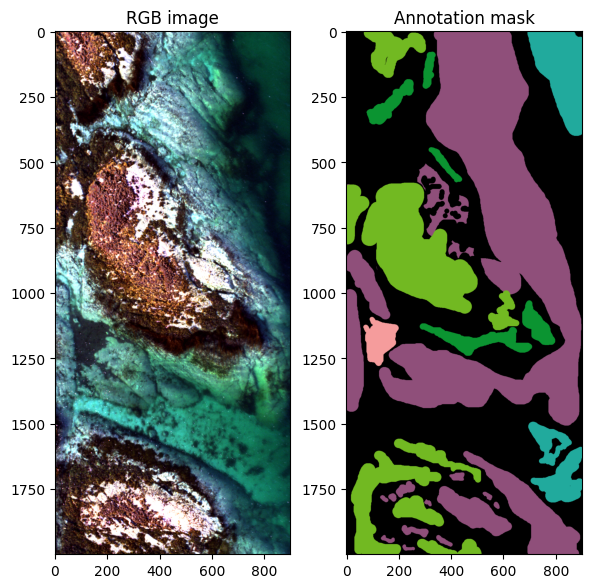

In [7]:
# Display RGB image and mask side by side
fig, ax = plt.subplots(1, 2, figsize=(6, 6))
ax[0].imshow(rgb_image)
ax[0].set_title("RGB image")
ax[1].imshow(mask_image)
ax[1].set_title("Annotation mask")
plt.tight_layout()

The left panel shows the RGB image and the right panel shows the annotations. Each annotation class has a unique color (tuple of RGB values) that identifies it. The names of each category and the corresponding RGB value can be read from a separate JSON file:

## Load annotation label metadata from JSON 

In [8]:
# Load segmentation info from JSON file
with open(mask_json_path, "r") as f:
    segmentation_info = json.load(f)

In [9]:
# Print first 3 classes in segmentation info, to show the data structure
rich.print(segmentation_info[:3])

[
    {
        'id': '5985f2e5-95f0-43b4-94a8-1b3d3701b450',
        'color': '#1f78b44d',
        'png_index': [31, 120, 180],
        'name': 'Deep water',
        'type': 'background',
        'description': 'Water where seabed is not visible (deeper than Secci depth)',
        'use_description_as_prompt': False
    },
    {
        'id': 'e4a696ba-f7a3-4ca3-bcc1-23138e907cf1',
        'color': '#6a3d9a4d',
        'png_index': [106, 61, 154],
        'name': 'Substrate',
        'type': 'background',
        'description': 'All types of substrate (most general class), not covered by vegetation.',
        'use_description_as_prompt': False
    },
    {
        'id': '5983af43-40c6-4bdd-bc6e-21dcaf7a78bc',
        'color': '#59243d4d',
        'png_index': [89, 36, 61],
        'name': 'Rock',
        'type': 'background',
        'description': 'General class for any type of rock (bedrock or "loose" rocks). To be used if it\'s not 
possible to determine type of rock in more detail.',
        'use_description_as_prompt': False
    }
]

In [10]:
# Use the segmentation info to make a binary mask for each class
masks = {}
mask_image_array = np.array(mask_image)
rock_png_index = None
for annotation_class in segmentation_info:
    masks[annotation_class["name"]] = np.all(
        mask_image_array == np.array(annotation_class["png_index"], dtype=np.uint8),
        axis=2,
    )

Here we make a dictionay with a binary mask for each separate category. Depending on the use case, you may want to format the masks differently - this is just an example. 

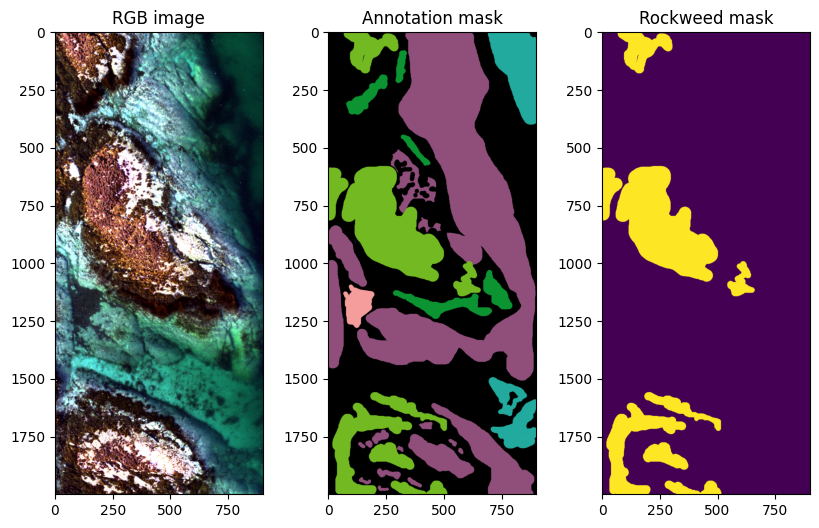

In [11]:
# Plot the "Rockweed" mask with the RGB image and original annotation mask
fig, ax = plt.subplots(1, 3, figsize=(10, 6))
ax[0].imshow(rgb_image)
ax[0].set_title("RGB image")
ax[1].imshow(mask_image)
ax[1].set_title("Annotation mask")
ax[2].imshow(masks["Rockweed"])
ax[2].set_title("Rockweed mask")
plt.show()

We see that the "Rockweed" category, which is singled out in the right panel, corresponds to the light green color in the original annotation PNG image (center panel).

# Load annotations in COCO format
The second format for annotations is the format used for "[Common Objects in Context](https://cocodataset.org/)" (COCO) dataset. In this case, the annotations cannot be viewed directly as images - they are stored as pure metadata in a JSON file. Luckily, the pycocotools library makes is easy to read and decode this metadata. 

In [12]:
# Load annotations in COCO format and print info
coco = COCO(coco_json_path)
print("----")
coco.info()
print(f"Number of images: {len(coco.imgs)}")
print(f"Number of annotations: {len(coco.anns)}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
----
year: 2025
date_created: 2024-02-27T12:26:08Z
version: 1.0
description: Massimal RGB versions of hyperspectral images from multiple locations, recorded as part of the Massimal project
contributor: 
url: https://app.hasty.ai/projects/2fdcaecd-c745-46c3-b775-26933e5a5e24
Number of images: 132
Number of annotations: 463


In [13]:
# Load and print annotation categories
coco.loadCats(coco.getCatIds())

[{'id': 1, 'name': 'Deep water', 'supercategory': 'background'},
 {'id': 2, 'name': 'Substrate', 'supercategory': 'background'},
 {'id': 3, 'name': 'Rock', 'supercategory': 'background'},
 {'id': 4, 'name': 'Bedrock', 'supercategory': 'background'},
 {'id': 5, 'name': 'Boulder', 'supercategory': 'background'},
 {'id': 6, 'name': 'Cobble', 'supercategory': 'background'},
 {'id': 7, 'name': 'Gravel', 'supercategory': 'background'},
 {'id': 8, 'name': 'Sediment', 'supercategory': 'background'},
 {'id': 9, 'name': 'Sand', 'supercategory': 'background'},
 {'id': 10, 'name': 'Mud', 'supercategory': 'background'},
 {'id': 11, 'name': 'Algae', 'supercategory': 'background'},
 {'id': 12, 'name': 'Brown algae', 'supercategory': 'background'},
 {'id': 13, 'name': 'Kelp', 'supercategory': 'background'},
 {'id': 14, 'name': 'Laminaria hyperborea', 'supercategory': 'background'},
 {'id': 15, 'name': 'Laminaria digitata', 'supercategory': 'background'},
 {'id': 16, 'name': 'Sacchoriza polyides', 'sup

Again, we simplify the process by focusing on a single example image. We search for the image index among the COCO annotations based on the same base name as before: 

In [14]:
# Find index for example image
example_image_rgb_file_name = EXAMPLE_IMAGE_BASENAME + ".png"
coco_example_image_index = -1  # Placeholder
for img_id, img_info in coco.imgs.items():
    if img_info["file_name"] == example_image_rgb_file_name:
        coco_example_image_index = img_id
        break
print(f"Index for example image: {coco_example_image_index}")


Index for example image: 63


In [15]:
# Print image information for example image
print("Example image information:\n----")
for key, value in coco.imgs[coco_example_image_index].items():
    print(f"{key}: {value}")

Example image information:
----
id: 63
width: 900
height: 2000
file_name: massimal_vega_sola_202208231608-coast3_hsi_013.png
license: None
flickr_url: 
coco_url: None
date_captured: 2024-03-11T14:44:11Z


In [16]:
# Print example annotation data
print("Example image information:\n----")
for key, value in coco.anns[coco_example_image_index].items():
    print(f"{key}: {value}")

Example image information:
----
id: 63
image_id: 98
category_id: 12
segmentation: {'size': [2000, 900], 'counts': 'TTWS1f0em1;G6J5M3L4M2M4@?J6L4L4N2M3N2M3N1_MQN`XNQ2Zg1ZN_XNg1^g1_N^XNc1^g1bN\\XNc1bg1aNXXNb1fg1fNQXN^1mg1fNmWN]1Qh1c2N1O1O2N1O1@`0K5M4L3O100000000000O10000001O1O1O1O1ZYNRIhe1o6RZN\\Ihe1e6TZNaIie1e7N=C6J3M;E6JR1nN6J3M2N2N4L6J3M2N2N2N3M2N2N2N1U^NeE__1]:Y`NoEa_1c<M2N2N2N1O2N1O1O1O1O1O1O001O001O1O001O001O00001O000000001O00000000000000O10000000000O100O10000O100O100O1O100O1O1O1O1O1O1O1O1N2O1N2O1N2M3M3K5\\Od0M3M3K5I7M3M3L4N2O1M3N2M3M3K5A?O1O1O1O1O1O1O1O1OTCPGXjNZ1m5e7go0aKSPO^4ko0hKRPOW4lo0YOglNf0YS1B`lN=_S1I]lN6cS1OYlN0fS15WlNIjS1:TlNElS1>RlN@oS1c0okN\\OQT1g0mkNXOST1k0kkNTOUT1o0ikNPOXT1R1fkNmNZT1U1ekNjN[T1Y1ckNeN_T1\\1`kNcN`T1_1_kN_NcT1b1\\kN]NdT1e1[kNXNgT1j1XkNSNiT1P2VkNZKWOUJgU1b:RkNVKAeIhU1W;fjNQKJ`IbU1a;cjNnJ4TI]U1o;_jNlJeW1V5ZhNkJdW1W5[hNkJbW1W5]hNjJbW1W5]hNkJ`W1W5_hNjJf`0XIn3P<[[OiJa`0bIn3f;`[OiJ^`0gIn3b;c[OhJS`0SJX4V;d[OiJm?XJ\\4Q;f[OiJi?[JeAgM[`0V=V^OjJe?]JdAnM[`0l<[^OjJc

The actual pixel-by-pixel annotation is the "counts" data, which is [run length encoded](https://en.wikipedia.org/wiki/Run-length_encoding), and has to be decoded before use. We loop over all the categories in the dataset and create a dictionary with binary masks for each cactegory. Again, formatting of such label masks should be adapted according to specific analysis needs.

In [ ]:
# Create label masks from COCO annotations for example image
image_size = (
    coco.imgs[coco_example_image_index]["height"],
    coco.imgs[coco_example_image_index]["width"],
)
coco_masks = {}

# Loop over categories and create a binary mask for each category
for category in coco.loadCats(coco.getCatIds()):
    coco_masks[category["name"]] = np.zeros(image_size, dtype=np.bool)  # type: ignore

    # Loop over annotations for the example image and fill in the binary mask
    for ann in coco.loadAnns(coco.getAnnIds(imgIds=coco_example_image_index)):
        if ann["category_id"] == category["id"]:
            ann_binary_mask = pycocotools.mask.decode(ann["segmentation"]).astype(bool)  # type: ignore
            coco_masks[category["name"]][ann_binary_mask] = 1

Note that the "hard work" of decoding the annotations is done with the `pycocotools.mask.decode()` function. 

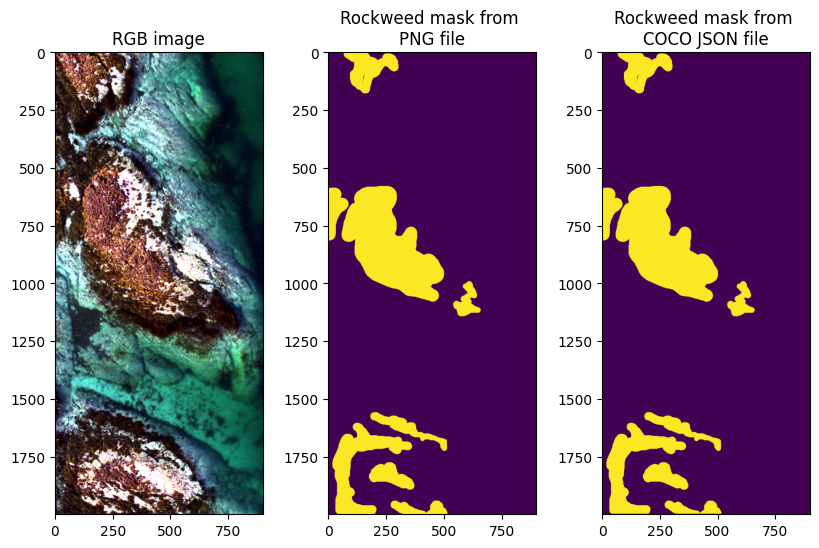

In [18]:
# Plot the "Rockweed" mask with the RGB image, mask from PNG file and mask from COCO annotations
fig, ax = plt.subplots(1, 3, figsize=(10, 6))
ax[0].imshow(rgb_image)
ax[0].set_title("RGB image")
ax[1].imshow(masks["Rockweed"])
ax[1].set_title("Rockweed mask from \nPNG file")
ax[2].imshow(coco_masks["Rockweed"])
ax[2].set_title("Rockweed mask from \nCOCO JSON file")
plt.show()

Finally, we can compare the masks for an example category ("Rockweed") for our example image, and we can confirm that they are the same. In the end, the choice of using PNG masks or COCO annotations is up to the user. 